# Simulation Game of Trading given Model Predictions

### Parameter Setting:
- Set your starting capital
- Set conversion rate to USD 
- Set brokerage fee per trade of your desired platform
- Set threshold for investment or disinvestment based on model prediction confidence

In [ ]:
# Parameters
STARTING_CAPITAL_CHF = 1000
CHF_USD_RATE = 0.88  # Approximate CHF to USD conversion
TRANSACTION_COST_PCT = 0.001  # 0.1% per trade (typical for ETFs)
THRESHOLD = 0.2  # Only trade if predicted return > 0.1% or < -0.1%

# Convert to USD
capital_usd = STARTING_CAPITAL_CHF * CHF_USD_RATE

### Data Download and Simulation

In [2]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import os

# Remove old credentials if needed
if 'GOOGLE_APPLICATION_CREDENTIALS' in os.environ:
    del os.environ['GOOGLE_APPLICATION_CREDENTIALS']

# Initialize BigQuery
client = bigquery.Client(project='trading-brains')

In [3]:
# Fetch predictions and actuals
query = """
SELECT 
  TIMESTAMP(p.timestamp) as timestamp,
  p.last_price,
  p.pred_60m,
  p.return_60m as predicted_return,
  a.actual_60m_price,
  (a.actual_60m_price - p.last_price) / p.last_price * 100 as actual_return
FROM `trading-brains.tft_predictions.tft_predictions_logs` p
JOIN `trading-brains.tft_predictions.tft_actuals` a
  ON p.timestamp = a.prediction_timestamp
ORDER BY p.timestamp
"""
df = client.query(query).to_dataframe()

c:\Users\batzi\anaconda3\envs\trading_brains\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [5]:
# Initialize tracking
df['position'] = 0  # 1 = long, 0 = cash, -1 = short (if allowed)
df['shares'] = 0.0
df['cash'] = capital_usd
df['portfolio_value'] = capital_usd
df['trade_action'] = 'HOLD'

In [6]:
# Simulate Trades

cash = capital_usd
shares = 0
position = 0

for i in range(len(df)):
    row = df.iloc[i]
    predicted_return = row['predicted_return']
    price = row['last_price']
    
    # Trading logic
    if predicted_return > THRESHOLD and position == 0:
        # BUY signal - go long
        shares_to_buy = (cash * (1 - TRANSACTION_COST_PCT)) / price
        shares = shares_to_buy
        cash = 0
        position = 1
        df.loc[df.index[i], 'trade_action'] = 'BUY'
        
    elif predicted_return < -THRESHOLD and position == 1:
        # SELL signal - exit position
        cash = shares * price * (1 - TRANSACTION_COST_PCT)
        shares = 0
        position = 0
        df.loc[df.index[i], 'trade_action'] = 'SELL'
    
    # Calculate portfolio value
    if position == 1:
        # Use actual price 60 min later for portfolio value
        actual_price = row['actual_60m_price'] if pd.notna(row['actual_60m_price']) else price
        portfolio_value = shares * actual_price
    else:
        portfolio_value = cash
    
    df.loc[df.index[i], 'shares'] = shares
    df.loc[df.index[i], 'cash'] = cash
    df.loc[df.index[i], 'position'] = position
    df.loc[df.index[i], 'portfolio_value'] = portfolio_value

In [ ]:
# PERFORMANCE METRICS

final_value_usd = df['portfolio_value'].iloc[-1]
final_value_chf = final_value_usd / CHF_USD_RATE

total_return_pct = (final_value_chf - STARTING_CAPITAL_CHF) / STARTING_CAPITAL_CHF * 100
num_trades = len(df[df['trade_action'] != 'HOLD'])

# Calculate daily returns for Sharpe ratio
df['daily_return'] = df['portfolio_value'].pct_change()
sharpe_ratio = df['daily_return'].mean() / df['daily_return'].std() * np.sqrt(252)  # Annualized

print("="*50)
print("TRADING SIMULATION RESULTS")
print("="*50)
print(f"Starting Capital: {STARTING_CAPITAL_CHF:.2f} CHF")
print(f"Final Value: {final_value_chf:.2f} CHF")
print(f"Total Return: {total_return_pct:.2f}%")
print(f"Number of Trades: {num_trades}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print("="*50)

# Show trade history
print("\nTrade History:")
print(df[df['trade_action'] != 'HOLD'][['timestamp', 'trade_action', 'last_price', 'predicted_return', 'portfolio_value']])

IndexError: single positional indexer is out-of-bounds

IndexError: single positional indexer is out-of-bounds

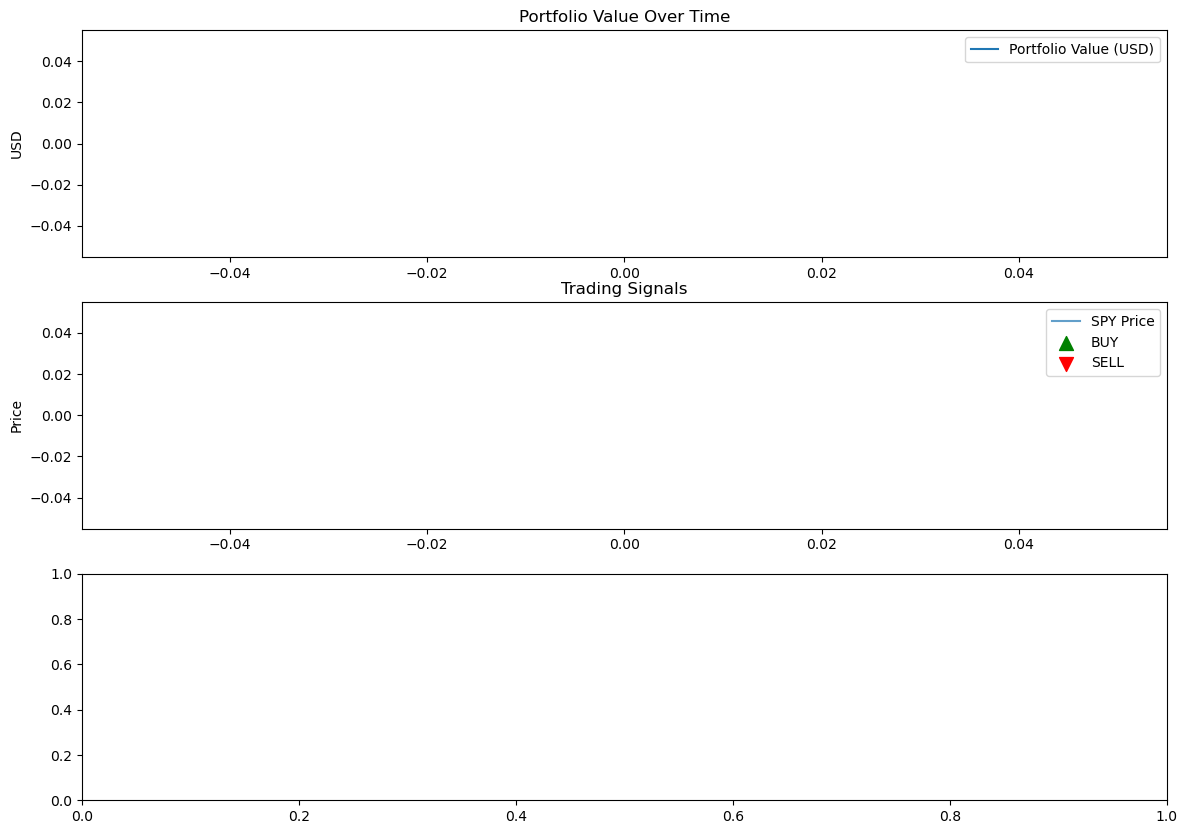

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Portfolio value over time
axes[0].plot(df['timestamp'], df['portfolio_value'], label='Portfolio Value (USD)')
axes[0].set_title('Portfolio Value Over Time')
axes[0].set_ylabel('USD')
axes[0].legend()

# Buy/Sell signals on price chart
axes[1].plot(df['timestamp'], df['last_price'], label='SPY Price', alpha=0.7)
buys = df[df['trade_action'] == 'BUY']
sells = df[df['trade_action'] == 'SELL']
axes[1].scatter(buys['timestamp'], buys['last_price'], color='green', marker='^', s=100, label='BUY')
axes[1].scatter(sells['timestamp'], sells['last_price'], color='red', marker='v', s=100, label='SELL')
axes[1].set_title('Trading Signals')
axes[1].set_ylabel('Price')
axes[1].legend()

# Cumulative returns comparison
df['strategy_cumret'] = (df['portfolio_value'] / df['portfolio_value'].iloc[0] - 1) * 100
df['buyhold_cumret'] = (df['last_price'] / df['last_price'].iloc[0] - 1) * 100
axes[2].plot(df['timestamp'], df['strategy_cumret'], label='Strategy')
axes[2].plot(df['timestamp'], df['buyhold_cumret'], label='Buy & Hold', linestyle='--')
axes[2].set_title('Strategy vs Buy & Hold')
axes[2].set_ylabel('Return (%)')
axes[2].legend()

plt.tight_layout()
plt.show()